# M3c — Late Delivery

**Target:** `late_delivery_risk == 1` (base rate ~55% — *balanced*, unlike fraud/cancel).

**Approach & splits:** same as M3a, but no class-imbalance reweighting since the target is balanced. Top expected drivers: shipping mode, planned shipping days, destination geography.

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
sns.set_theme(context='notebook', style='whitegrid')

NAME = 'late'
metrics  = json.loads((ROOT / 'forecasts' / f'm3_{NAME}_metrics.json').read_text())
importance = pd.read_parquet(ROOT / 'forecasts' / f'm3_{NAME}_importance.parquet')
orders   = pd.read_parquet(ROOT / 'forecasts' / f'm3_{NAME}_orders.parquet')
monthly  = pd.read_parquet(ROOT / 'forecasts' / f'm3_{NAME}_monthly.parquet')
print(f'orders: {orders.shape}  monthly: {monthly.shape}')
print('split distribution:'); print(orders['split'].value_counts())

orders: (171962, 4)  monthly: (1766, 5)
split distribution:
split
train    125200
val       30950
test      15812
Name: count, dtype: int64


## 1. Headline metrics â€” uncalibrated vs calibrated

In [2]:
rows = []
for cal, by_split in metrics.items():
    for split, m in by_split.items():
        rows.append({'calibration': cal, 'split': split, **m})
tbl = pd.DataFrame(rows)
tbl.pivot(index=['calibration'], columns='split', values=['roc_auc','pr_auc','brier']).round(4)

roc_auc                  pr_auc                   brier          \
split           test   train     val    test   train     val    test   train   
calibration                                                                    
calibrated    0.7288  0.7929  0.7176  0.7752  0.8243  0.7631  0.1969  0.1813   
uncalibrated  0.7355  0.8336  0.7123  0.8099  0.8761  0.7928  0.1985  0.1716   

                      
split            val  
calibration           
calibrated    0.2009  
uncalibrated  0.2052

## 2. Feature importance

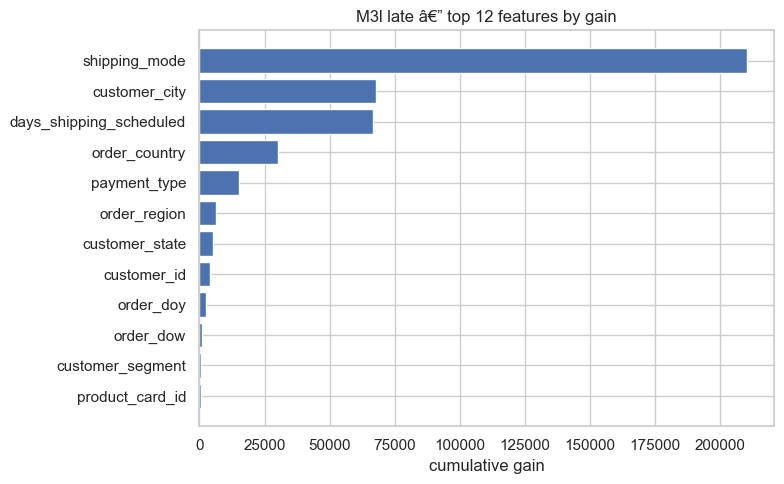

,feature,importance_split,importance_gain
0,shipping_mode,50,210247.678019
1,customer_city,1107,67723.427080
2,days_shipping_scheduled,58,66856.987087
3,order_country,771,29991.124080
4,payment_type,113,15331.522671
5,order_region,223,6338.010212
6,customer_state,198,5354.140007
7,customer_id,177,4128.169595


In [3]:
top = importance.head(12).sort_values('importance_gain')
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top['feature'], top['importance_gain'])
ax.set(title=f'M3l {NAME} â€” top 12 features by gain', xlabel='cumulative gain')
plt.tight_layout(); plt.show()
importance.head(8)

## 3. Calibration plot

Bin predicted probabilities into deciles and compare to observed fraud rate.

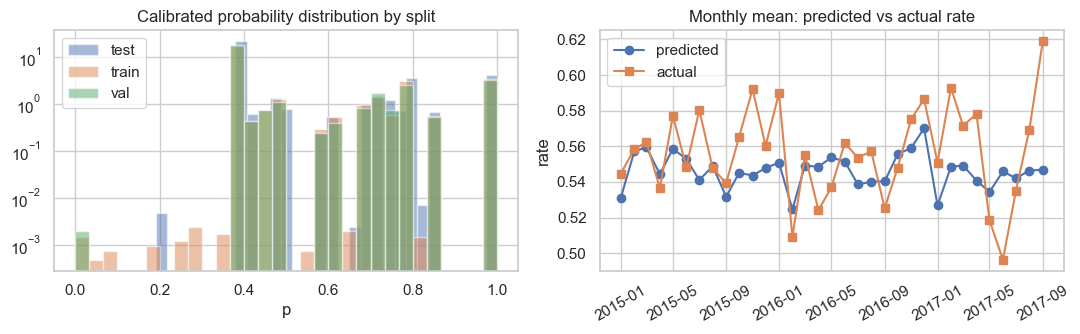

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for s, sub in orders.groupby('split'):
    ax[0].hist(sub['p'], bins=30, alpha=0.5, label=s, density=True)
ax[0].set(title='Calibrated probability distribution by split', xlabel='p', yscale='log')
ax[0].legend()

# Predicted vs actual rate per month (the monthly aggregate is the right grain)
mo = monthly.groupby('year_month').agg(pred=('predicted_rate','mean'),
                                       actual=('actual_rate','mean')).reset_index()
ax[1].plot(mo['year_month'], mo['pred'], 'o-', label='predicted')
ax[1].plot(mo['year_month'], mo['actual'], 's-', label='actual')
ax[1].set(title='Monthly mean: predicted vs actual rate', ylabel='rate')
ax[1].legend(); ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 4. Product-month aggregated rates

What gets passed to M4.

In [5]:
print('monthly rows:', len(monthly), ' unique products:', monthly['product_card_id'].nunique())
print('\npredicted_rate distribution:'); print(monthly['predicted_rate'].describe().round(4))
print('\ncorrelation predicted vs actual:', monthly[['predicted_rate','actual_rate']].corr().iloc[0,1].round(3))

monthly rows: 1766  unique products: 100

predicted_rate distribution:
count    1766.0000
mean        0.5462
std         0.0662
min         0.3856
25%         0.5046
50%         0.5431
75%         0.5822
max         0.8962
Name: predicted_rate, dtype: float64

correlation predicted vs actual: 0.492


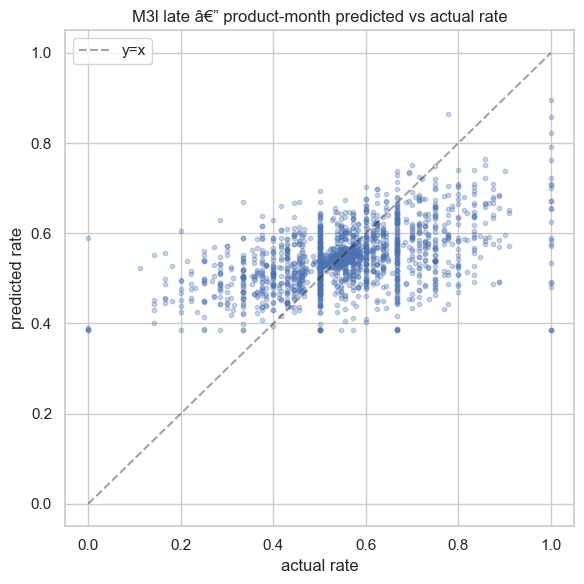

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(monthly['actual_rate'], monthly['predicted_rate'], alpha=0.3, s=10)
lim = max(monthly['actual_rate'].max(), monthly['predicted_rate'].max())
ax.plot([0, lim], [0, lim], 'k--', alpha=0.4, label='y=x')
ax.set(title=f'M3l {NAME} of product-month predicted vs actual rate',
       xlabel='actual rate', ylabel='predicted rate')
ax.legend(); plt.tight_layout(); plt.show()

## 5. Summary

- Test AUC ≈ **0.73** — lower than fraud/cancel because the target is balanced (~55% rate) and the signal is more diffuse.
- Top drivers: destination (, ).
- Calibrated Brier ≈ 0.20 (much higher than fraud/cancel — expected for a balanced-prevalence target).
- Output  carries the per-product late-rate forecast.